In [45]:
import mudata as md
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, Trace_ELBO, JitTraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.optim import Adam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

smoke_test = True

In [46]:
adata = md.read("/Users/ljb80/Data/gasperini_pilot/GasperiniShendure2019_lowMOI.h5ad")
adata

AnnData object with n_obs × n_vars = 41284 × 32738
    obs: 'sample', 'total_umis', 'Size_Factor', 'gene', 'all_gene', 'barcode', 'read_count', 'umi_count', 'proportion', 'guide_count', 'sample_directory', 'ko_barcode_file', 'sample_name', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [47]:
adata.obs["gene"].value_counts().head(50)

gene
nan                                  4473
DCTPP1_TSS                             37
ATPIF1_TSS                             37
TOP1_TSS                               36
ZNF593_TSS                             33
HES6_TSS                               32
HMGB3_TSS                              31
FAM83A_TSS                             31
FAM96A_TSS                             31
chr1:161359440-161359463               31
pos_control_HBE1_tss_Klann_mosaic      31
NPM1_TSS                               31
TMEM165_TSS                            31
EWSR1_TSS                              30
TSPO_TSS                               30
scrambled_2                            29
chrX:23817660-23817683                 29
chr2:65521752-65521775                 29
MPZL1_TSS                              28
NET1_TSS                               28
EIF4H_TSS                              28
TOMM7_TSS                              28
CSTB_TSS                               28
chr1:207919746-207919769     

In [31]:
# n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
# n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
# n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
# n_ribo = n_rps + n_rpl
# n_total = adata.X.sum(axis=1).A1
n_total = adata.obs["ncounts"]

n_mito = (adata.obs["percent_mito"] * n_total).astype(int)
n_ribo = (adata.obs["percent_ribo"] * n_total).astype(int)

# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)
print(n_ribo)
print(n_mito)

cell_barcode
AAACCTGAGTCGAGTG     295000
AAACCTGCAATTCCTT     859299
AAACCTGCACACATGT     213000
AAACCTGCACGCGAAA    1731300
AAACCTGCAGTTCCCT    1009700
                     ...   
TTTGTCAAGCCGTCGT     370800
TTTGTCAGTACATCCA     665100
TTTGTCAGTCATATGC     505000
TTTGTCAGTCTCGTTC    1370000
TTTGTCAGTTTGCATG     606800
Length: 24341, dtype: int64
cell_barcode
AAACCTGAGTCGAGTG    0
AAACCTGCAATTCCTT    0
AAACCTGCACACATGT    0
AAACCTGCACGCGAAA    0
AAACCTGCAGTTCCCT    0
                   ..
TTTGTCAAGCCGTCGT    0
TTTGTCAGTACATCCA    0
TTTGTCAGTCATATGC    0
TTTGTCAGTCTCGTTC    0
TTTGTCAGTTTGCATG    0
Length: 24341, dtype: int64


In [34]:
adata.obs["gene"]

cell_barcode
AAACCTGAGTCGAGTG                    TOP1_TSS
AAACCTGCAATTCCTT                  ZNF273_TSS
AAACCTGCACACATGT      chr4:84540211-84540234
AAACCTGCACGCGAAA      chr1:26826520-26826543
AAACCTGCAGTTCCCT     chr14:55569715-55569738
                              ...           
TTTGTCAAGCCGTCGT                   HDDC3_TSS
TTTGTCAGTACATCCA     chr22:30176603-30176626
TTTGTCAGTCATATGC                         nan
TTTGTCAGTCTCGTTC                   YWHAQ_TSS
TTTGTCAGTTTGCATG    chr6:144536589-144536612
Name: gene, Length: 24341, dtype: category
Categories (1759, object): ['ACTB_TSS', 'ACTG1_TSS', 'ACTG1_TSS_scrambled_13', 'ACYP1_TSS', ..., 'scrambled_21_TIMM17B_TSS', 'scrambled_22_SRP14_TSS', 'scrambled_24_SEPT11_TSS', 'scrambled_25_SLC25A39_TSS']

In [32]:
adata.obs = adata.obs.assign(element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True))
adata.obs["element"]

cell_barcode
AAACCTGAGTCGAGTG                        TOP1
AAACCTGCAATTCCTT                      ZNF273
AAACCTGCACACATGT      chr4:84540211-84540234
AAACCTGCACGCGAAA      chr1:26826520-26826543
AAACCTGCAGTTCCCT     chr14:55569715-55569738
                              ...           
TTTGTCAAGCCGTCGT                       HDDC3
TTTGTCAGTACATCCA     chr22:30176603-30176626
TTTGTCAGTCATATGC                         nan
TTTGTCAGTCTCGTTC                       YWHAQ
TTTGTCAGTTTGCATG    chr6:144536589-144536612
Name: element, Length: 24341, dtype: object

In [21]:
control_label = "control"
elements = [e for e in sorted(adata.obs["element"].unique()) if e != control_label]
element_mapping = {element: i + 1 for i, element in enumerate(elements)}
print(element_mapping)
adata.obs["element_id"] = adata.obs["element"].map(element_mapping)
adata.obs["element_id"] = adata.obs["element_id"].fillna(0).astype(int)
adata.obs[["element", "element_id"]]

{'ACTB': 1, 'ACTB_ALDH1A2_chr6:37178148-37178171': 2, 'ACTB_ATP5F1': 3, 'ACTB_ATP6V1F_chr19:2059423-2059446_chr2:43140342-43140365': 4, 'ACTB_AZIN1_chr5:10320939-10320962_PLEKHJ1_SEC11A': 5, 'ACTB_BROX': 6, 'ACTB_CCDC71L_chr11:34779831-34779854_chr21:45280531-45280554': 7, 'ACTB_COPS5': 8, 'ACTB_DLK1': 9, 'ACTB_EIF4EBP1': 10, 'ACTB_INSIG1': 11, 'ACTB_LAMTOR1': 12, 'ACTB_LARP1': 13, 'ACTB_NET1': 14, 'ACTB_NUS1': 15, 'ACTB_PRKAR2A': 16, 'ACTB_QKI': 17, 'ACTB_RER1': 18, 'ACTB_THOC2': 19, 'ACTB_chr10:112376245-112376268_chr2:135808281-135808304': 20, 'ACTB_chr10:43876203-43876226': 21, 'ACTB_chr10:74080224-74080247_chr1:110444237-110444260_chr1:235110514-235110537_chr13:48736080-48736103_chr1:76138202-76138225_chr18:9008861-9008884_chr4:154354191-154354214_chr7:100743307-100743330_chr7:140207710-140207733_chrX:102505860-102505883_chrX:47535302-47535325_EPB41_NMU_PRPS1_RPL23A_SEPT11_SMARCC1': 22, 'ACTB_chr11:102212503-102212526_chr8:131054182-131054205': 23, 'ACTB_chr11:5150664-5150687_chr1

,element,element_id
cell_barcode,,
AAACCTGAGTCGAGTG,TOP1,2725
AAACCTGCAATTCCTT,ZNF273,2763
AAACCTGCACACATGT,chr4:84540211-84540234,14522
AAACCTGCACGCGAAA,chr1:26826520-26826543,11179
AAACCTGCACTATCTT,chr14:69216270-69216293_chr19:34656285-34656308,6590
...,...,...
TTTGTCAGTCATATGC,nan,16471
TTTGTCAGTCTCGTTC,YWHAQ,2761
TTTGTCAGTTACCAGT,chr5:34587577-34587600_chrX:47535302-47535325_...,14758


In [7]:
control_label = "control"
guides = [e for e in sorted(adata.obs["perturbation"].unique()) if e != control_label]
guide_mapping = {guide: i + 1 for i, guide in enumerate(guides)}
print(guide_mapping)
adata.obs["guide_id"] = adata.obs["perturbation"].map(guide_mapping)
adata.obs["guide_id"] = adata.obs["guide_id"].fillna(0).astype(int)
adata.obs[["perturbation", "guide_id"]]

{'ATF2g1': 1, 'ATF2g2': 2, 'ATF2g3': 3, 'ATF2g4': 4, 'BRD4g1': 5, 'BRD4g2': 6, 'BRD4g3': 7, 'BRD4g4': 8, 'CAV1g1': 9, 'CAV1g2': 10, 'CAV1g3': 11, 'CAV1g4': 12, 'CD86g1': 13, 'CD86g2': 14, 'CD86g3': 15, 'CD86g4': 16, 'CMTM6g1': 17, 'CMTM6g2': 18, 'CMTM6g3': 19, 'CUL3g1': 20, 'CUL3g2': 21, 'CUL3g3': 22, 'ETV7g1': 23, 'ETV7g2': 24, 'ETV7g3': 25, 'ETV7g4': 26, 'IFNGR1g1': 27, 'IFNGR1g2': 28, 'IFNGR1g3': 29, 'IFNGR1g4': 30, 'IFNGR2g1': 31, 'IFNGR2g2': 32, 'IFNGR2g3': 33, 'IFNGR2g4': 34, 'IRF1g1': 35, 'IRF1g2': 36, 'IRF1g3': 37, 'IRF1g4': 38, 'IRF7g1': 39, 'IRF7g2': 40, 'IRF7g3': 41, 'IRF7g4': 42, 'JAK2g1': 43, 'JAK2g2': 44, 'JAK2g3': 45, 'JAK2g4': 46, 'MARCH8g1': 47, 'MARCH8g2': 48, 'MARCH8g3': 49, 'MARCH8g4': 50, 'MYCg1': 51, 'MYCg2': 52, 'MYCg3': 53, 'MYCg4': 54, 'NFKBIAg1': 55, 'NFKBIAg2': 56, 'NFKBIAg3': 57, 'NFKBIAg4': 58, 'PDCD1LG2g1': 59, 'PDCD1LG2g2': 60, 'PDCD1LG2g3': 61, 'PDCD1LG2g4': 62, 'POU2F2g1': 63, 'POU2F2g2': 64, 'POU2F2g3': 65, 'POU2F2g4': 66, 'SMAD4g1': 67, 'SMAD4g2': 68,

,perturbation,guide_id
AAACCTGAGCCAGAAC,STAT2g2,80
AAACCTGAGTGGACGT,CAV1g4,12
AAACCTGCATGAGCGA,STAT1g2,76
AAACCTGTCTTGTCAT,CD86g1,13
AAACGGGAGAACAACT,IRF7g2,40
...,...,...
TTTGTCAGTCACTTCC,CMTM6g1,17
TTTGTCAGTGACGGTA,control,0
TTTGTCAGTTCCACAA,ATF2g1,1
TTTGTCATCACGCATA,CAV1g2,10


In [8]:
# pick a subset of random genes including 3 known ones
stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones
stat_target_genes = list(element_mapping.keys())

if smoke_test:
    n_genes_subset = 50
    other_genes = [gene for gene in adata.var_names if gene not in stat_target_genes]
    selected_genes = stat_target_genes + other_genes[: n_genes_subset - len(stat_target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100
    adata_subset = adata[:,adata.X.sum(axis=0) > min_counts]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element', 'element_id'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [9]:
control_label = "control"
genes = adata_subset.var_names
gene_mapping = {gene: i + 1 for i, gene in enumerate(genes)}
# list(element_mapping.keys()).map(gene_mapping)

# for element, element_id in element_mapping.items():
# print(element_id, gene_mapping[element] if element in gene_mapping else 0)
target_gene_ids = [
    gene_mapping[element] if element in gene_mapping else 0 for element, element_id in element_mapping.items()
]
target_gene_ids
# adata_subset.obs["target_gene_id"] = adata_subset.obs["target_gene_id"].fillna(0).astype(int)
# adata_subset.obs[["element", "element_id", "target_gene_id"]]

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25]

In [10]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element,element_id
AAACCTGAGCCAGAAC,rep1-tx,80,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2,21
AAACCTGAGTGGACGT,rep1-tx,12,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1,3
AAACCTGCATGAGCGA,rep1-tx,76,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1,20
AAACCTGTCTTGTCAT,rep1-tx,13,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86,4
AAACGGGAGAACAACT,rep1-tx,40,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,17,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6,5
TTTGTCAGTGACGGTA,rep4-tx,0,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control,0
TTTGTCAGTTCCACAA,rep3-tx,1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2,1
TTTGTCATCACGCATA,rep3-tx,10,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1,3


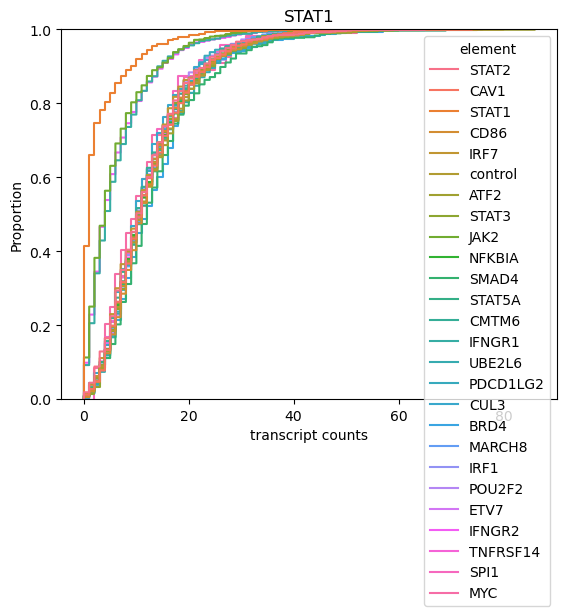

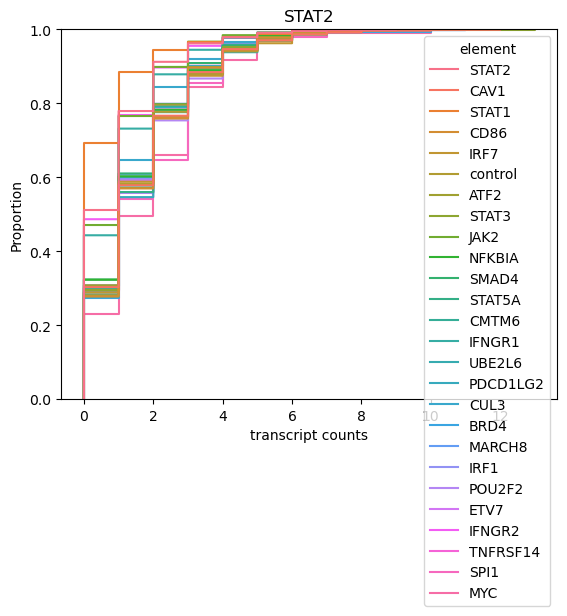

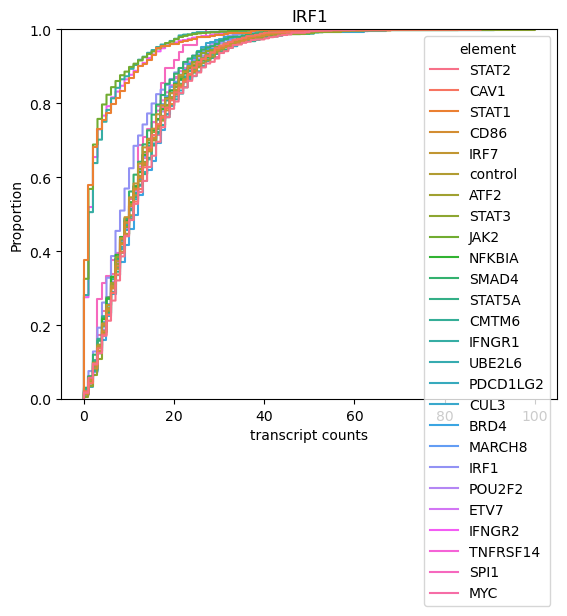

In [11]:
import seaborn as sns

# sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts = adata_subset[:, "IRF1"].X.todense().A1
# guide_ids = ["control"] + [f"STAT1g{i}" for i in range(1,5)]
# for guide_id in guide_ids:
# perts = adata.obs["guide_id"].str.contains(f"STAT1g{i}").values
for gene in ["STAT1", "STAT2", "IRF1"]:
    counts = adata_subset[:, gene].X.todense().A1
    sns.ecdfplot(x=counts, hue=adata_subset.obs["element"])
    plt.title(gene)
    plt.xlabel("transcript counts")
    plt.show()

In [12]:
covariate_cols = ["ncounts"]
adata_subset.X.sum(axis=0).A1

array([7.50900e+03, 3.23970e+04, 5.28000e+02, 5.06800e+03, 5.24190e+04,
       9.16000e+03, 5.60790e+04, 2.11900e+04, 1.15323e+05, 2.18361e+05,
       1.10917e+05, 4.80860e+04, 7.09000e+02, 1.54620e+04, 7.35920e+04,
       4.67000e+03, 1.10840e+04, 4.56500e+03, 1.98647e+05, 2.33330e+05,
       2.91440e+04, 4.39350e+04, 3.01400e+03, 3.19850e+04, 1.48627e+05,
       2.44000e+02, 1.25200e+03, 9.00000e+01, 2.54000e+02, 5.49000e+02,
       1.98700e+03, 3.36000e+02, 3.98000e+02, 2.97000e+02, 8.87400e+03,
       4.76000e+02, 6.74000e+02, 3.92000e+02, 1.12594e+05, 2.90200e+03,
       2.20000e+02, 1.52700e+03, 1.23000e+02, 1.37200e+03, 7.30530e+04,
       5.08100e+03, 7.42000e+02, 6.00000e+00, 2.02970e+04, 3.60000e+01],
      dtype=float32)

In [13]:
# read the data to tensors
counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32)
# counts = torch.tensor(adata_subset.X.todense(), dtype=torch.int32).to_sparse()
# counts = torch.sparse_csr_tensor(adata_subset.X, dtype=torch.int32)

# perturbations = torch.tensor(
#     adata_subset.obs["perturbation"].str.replace("STAT1g", "").str.replace("control", "0").values.astype(int),
#     dtype=torch.long,
# )
guide_ids = torch.tensor(adata_subset.obs["guide_id"].values, dtype=torch.long)
element_ids = torch.tensor(adata_subset.obs["element_id"].values, dtype=torch.long)
target_ids = torch.tensor(target_gene_ids, dtype=torch.long)
target_ids_matrix = torch.nn.functional.one_hot(target_ids, num_classes=counts.shape[1]+1)[:,1:]
print(target_ids_matrix)

lib_size = torch.tensor(adata_subset.obs["ncounts"].values)
size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)
gene_mean = torch.tensor(adata_subset.X.mean(axis=0).A1)
# covariates = torch.tensor(adata_subset.obs[covariate_cols].values)
# covariates = torch.hstack(torch.ones((n_cells,)), covariates)

# get data shapes
n_guides = int(guide_ids.max())
n_elements = int(element_ids.max())
n_cells, n_genes = counts.shape
# n_covariates = len(covariate_cols) + 1

print(n_guides, n_elements, n_cells, n_genes)

# print(lib_size.unsqueeze(dim=-1).log())

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [0, 1, 0,  ..., 0, 0, 0],
        [0, 0, 1,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
98 25 20729 50


/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_86033/780054640.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  size_factor = torch.tensor(lib_size.unsqueeze(-1).log() - lib_size.log().mean(), dtype=torch.float32)


(array([ 570., 1458., 2670., 4007., 4830., 4042., 2245.,  763.,  133.,
          11.]),
 array([-1.36212385, -1.04376841, -0.72541302, -0.40705764, -0.08870222,
         0.22965318,  0.54800856,  0.866364  ,  1.18471944,  1.50307477,
         1.82143021]),
 <BarContainer object of 10 artists>)

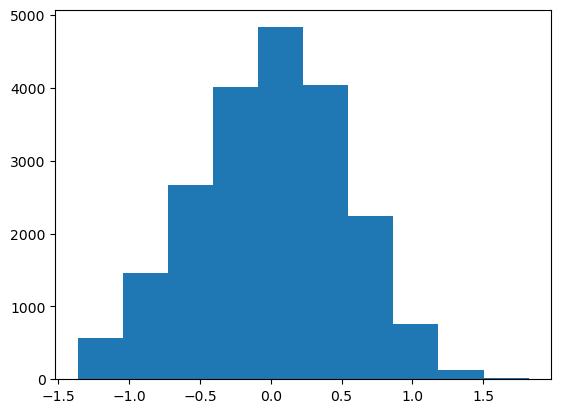

In [14]:
plt.hist(size_factor.squeeze())

/Users/ljb80/mambaforge/envs/pyro/lib/python3.10/site-packages/torch/distributions/distribution.py:167: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


tensor(0.0553)

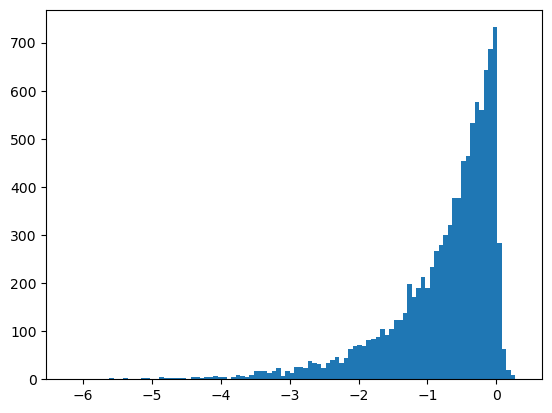

In [15]:
asym_laplace_samples = dist.AsymmetricLaplace(0.0, 0.2, 4).sample_n(10000)
plt.hist(asym_laplace_samples, bins=100)
(asym_laplace_samples>0).float().mean()

In [16]:
dist.Exponential(0.05).sample_n(10)

tensor([ 5.1413,  2.0667, 14.1170,  4.2617, 17.5704,  2.9942, 76.6618, 61.6703,
        17.8938, 89.9606])

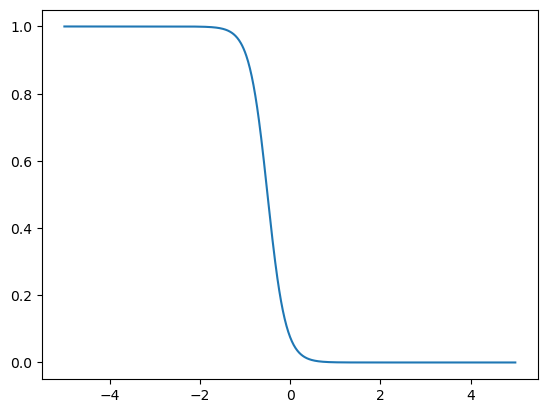

In [17]:
x_0 = -0.5
scale=5
x = torch.arange(-5, 5, 0.01)
y = torch.sigmoid(scale*(x_0-x))
plt.plot(x,y)

(array([  1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   1.,   1.,
          3.,   0.,   1.,   1.,   3.,   4.,   3.,   4.,   5.,   4.,   7.,
          7.,   6.,  12.,  17.,  11.,  16.,  28.,  26.,  25.,  39.,  53.,
         45.,  51.,  80.,  65.,  94., 114., 147., 155., 219., 235., 282.,
        340., 386., 429., 497., 625., 706., 767., 693., 544., 471., 414.,
        311., 280., 257., 217., 206., 148., 120., 133., 100.,  93.,  66.,
         56.,  62.,  56.,  40.,  27.,  23.,  23.,  24.,  18.,  20.,  11.,
         11.,   9.,   6.,   3.,   6.,   4.,   7.,   4.,   3.,   2.,   3.,
          1.,   1.,   2.,   1.,   1.,   1.,   0.,   3.,   0.,   0.,   0.,
          1.]),
 array([-0.83359975, -0.81702119, -0.80044264, -0.78386414, -0.76728559,
        -0.75070703, -0.73412848, -0.71754998, -0.70097142, -0.68439287,
        -0.66781431, -0.65123582, -0.63465726, -0.61807871, -0.60150015,
        -0.58492166, -0.5683431 , -0.55176455, -0.53518599, -0.5186075 ,
        -0.50202894, -0.48

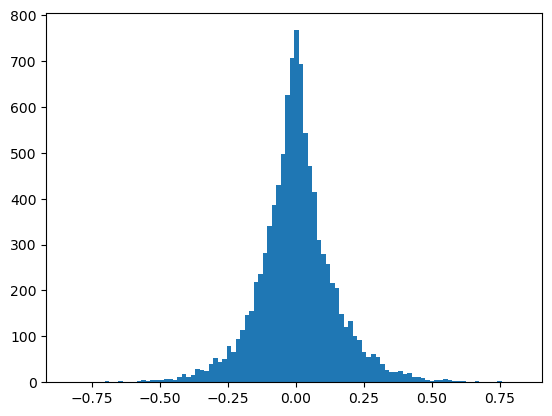

In [18]:
laplace_samples = dist.Laplace(0.0, 0.1).sample_n(10000)
plt.hist(laplace_samples, bins=100)


In [19]:
# @config_enumerate
# def model(
#     counts,
#     guide_ids,
#     element_ids,
#     target_ids,
#     n_factors=None,  # number of latent factors/confounders
#     size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
#     n_genes=1,
#     subsample_size=None,
# ):
#     n_guides = int(guide_ids.max())
#     n_elements = int(element_ids.max())
#     if counts is not None:
#         n_cells, n_genes = counts.shape
#     else:
#         assert guide_ids.shape == element_ids.shape
#         (n_cells,) = element_ids.shape
#     assert target_ids.shape == (n_elements, n_genes)
#     guides_plate = pyro.plate("guides", n_guides, dim=-2)
#     elements_plate = pyro.plate("elements", n_elements, dim=-2)
#     cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
#     genes_plate = pyro.plate("genes", n_genes, dim=-1)
#     pcs_plate = pyro.plate("factors", n_factors, dim=-3)
#     assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))

#     if n_factors is not None:
#         with cells_plate, pcs_plate:
#             pcs = pyro.sample("ppc_factors", dist.Normal(0, 1)).squeeze(dim=-1).transpose(-1, -2)  # cells x factors
#         with genes_plate, pcs_plate:
#             loadings = pyro.sample("ppc_loadings", dist.Normal(0, 1)).squeeze(-2)  # factors x genes

#     with guides_plate:
#         efficiency = pyro.sample("efficiency", dist.Beta(10.0, 1.0))
#     efficiency = torch.vstack((torch.tensor(0), efficiency))  # add dummy value for NTC guides
#     # efficiency = torch.full((n_guides + 1,), efficiency)
#     with cells_plate as idx:
#         guide_ids = guide_ids[idx]
#         affected = pyro.sample("affected", dist.Bernoulli(probs=efficiency[guide_ids], validate_args=True))

#         # with guides_plate:
#         # with elements_plate:

#         # effect = pyro.sample("effect", dist.Normal(0.0, 3.0))

#     with elements_plate:
#         cis_effect = pyro.sample("cis_effect", dist.AsymmetricLaplace(0.0, 0.2, 4))

#     with genes_plate:
#         mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
#         dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))

#         # print(ontarget_beta.shape)
#         # ontarget_effect_element =

#         # with guides_plate:
#         with elements_plate:
#             # is_target = pyro.sample("is_target", dist.Bernoulli(probs=0.01, validate_args=True))
#             # trans_effect = pyro.sample("trans_effect", dist.Normal(0.0, 0.1)) * torch.exp(3.0 * is_target)
#             trans_effect = pyro.sample("trans_effect", dist.Cauchy(0.0, 0.1))
#             # effect = pyro.sample("effect", dist.Normal(0.0, 3.0))
#         total_effect_padded = torch.vstack(
#             (torch.zeros(1, n_genes), cis_effect * target_ids + trans_effect * (1 - target_ids))
#         )
#         # beta = torch.vstack((torch.zeros(1, n_genes), total_effect))  # add dummy column for "control" element
#         # cis_effect = Vindex(ontarget_beta[:, None])[target_ids_padded]
#         # print(cis_effect.shape, cis_effect, beta.shape)

#         with cells_plate as idx:
#             element_ids = element_ids[idx]
#             if counts is not None and subsample_size is not None:
#                 counts = counts[idx, :]
#             size_factor = size_factor[idx, :]
#             logits = (
#                 # cis_effect_padded[element_ids, :] * affected  # mixture model only for cis effect
#                 # + trans_effect_padded[element_ids, :] * affected
#                 total_effect_padded[element_ids, :] * affected + mean.log() + size_factor
#             )
#             if n_factors is not None:
#                 logits += pcs @ loadings
#             # obs = pyro.sample("counts", dist.Poisson(logits.exp() + epsilon), obs=counts)
#             obs = pyro.sample(
#                 "counts",
#                 dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()),
#                 obs=counts,
#             )
#     return obs


# args = (counts, guide_ids, element_ids, target_ids_matrix)
# kwargs = {
#     "size_factor": size_factor,
#     # "subsample_size": 1024,
#     "n_factors": 5,
#     "n_genes": n_genes,
# }
# render_model(model, model_args=args, model_kwargs=kwargs, render_distributions=True)
# # render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

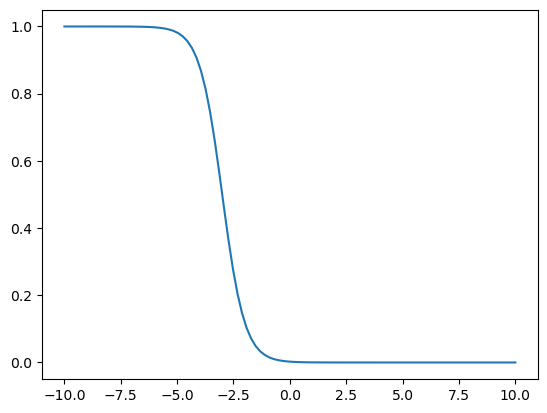

In [20]:
# relu = torch.nn.ReLU()
# relu = torch.nn.LeakyReLU()
# relu = lambda x: x
sigmoid = torch.nn.Sigmoid()
x = torch.tensor(np.linspace(-10, 10, 100))
k = 2
plt.plot(x, sigmoid((-x-3)*k))

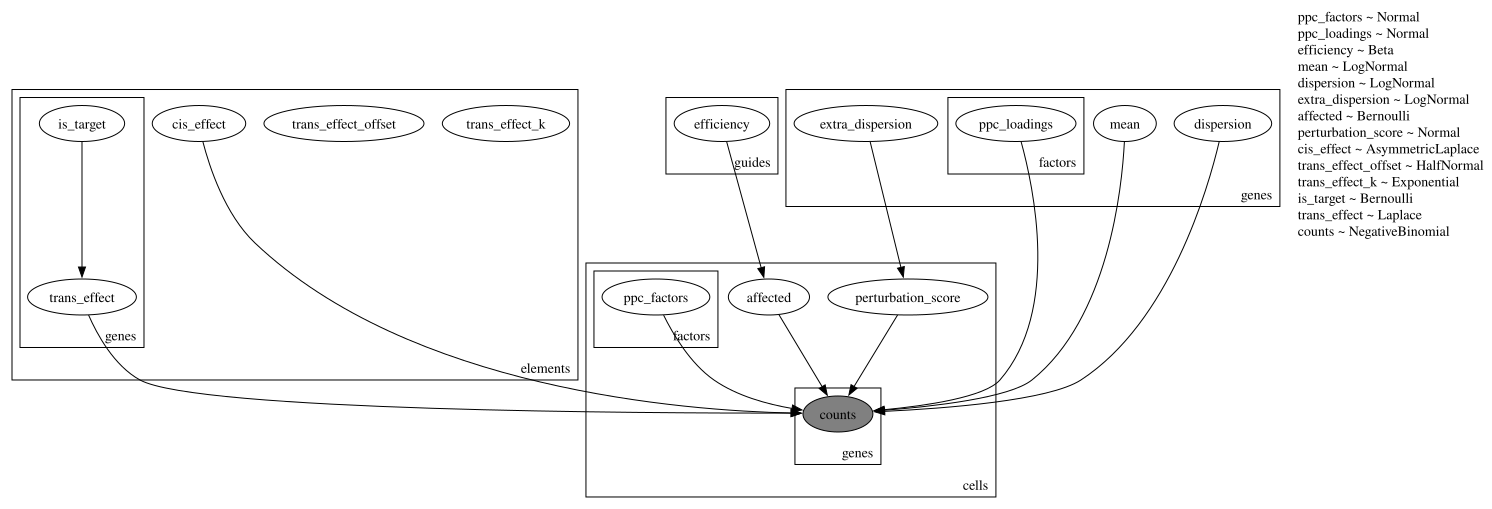

In [21]:
@config_enumerate
def model_fancy(
    counts,
    guide_ids,
    element_ids,
    target_ids,
    n_factors=None,  # number of latent factors/confounders
    size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
    n_genes=1,
    subsample_size=None,
    use_perturbation_mixture=True,
    use_perturbation_score=False,
    n_guides=None,
    n_elements=None,
    epsilon=1e-6,
):
    if n_guides is None:
        n_guides = int(guide_ids.max())
    if n_elements is None:
        n_elements = int(element_ids.max())
    if counts is not None:
        n_cells, n_genes = counts.shape
    else:
        assert guide_ids.shape == element_ids.shape
        (n_cells,) = element_ids.shape
    assert target_ids.shape == (n_elements, n_genes)
    guides_plate = pyro.plate("guides", n_guides, dim=-2)
    elements_plate = pyro.plate("elements", n_elements, dim=-2)
    cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    genes_plate = pyro.plate("genes", n_genes, dim=-1)
    pcs_plate = pyro.plate("factors", n_factors, dim=-3)
    assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))

    if n_factors is not None:
        with cells_plate, pcs_plate:
            pcs = pyro.sample("ppc_factors", dist.Normal(0, 1)).squeeze(dim=-1).transpose(-1, -2)  # cells x factors
        with genes_plate, pcs_plate:
            loadings = pyro.sample("ppc_loadings", dist.Normal(0, 1)).squeeze(-2)  # factors x genes

    with guides_plate:
        # efficiency_alpha = pyro.param("efficiency_alpha", torch.tensor((10.0,)), constraint=dist.constraints.positive)
        # efficiency_beta = pyro.param("efficiency_beta", torch.tensor((1.0,)), constraint=dist.constraints.positive)
        efficiency = pyro.sample("efficiency", dist.Beta(1.0, 1.0))
    efficiency = torch.vstack((torch.tensor(0), efficiency))  # add dummy value for NTC guides

    with genes_plate:
        mean = pyro.sample("mean", dist.LogNormal(0.0, 10.0))
        dispersion = pyro.sample("dispersion", dist.LogNormal(3.0, 5.0))
        pert_dispersion = pyro.sample("extra_dispersion", dist.LogNormal(-1.0, 3.0))

    with cells_plate as idx:
        guide_ids = guide_ids[idx]
        element_ids = element_ids[idx]
        if counts is not None and subsample_size is not None:
            counts = counts[idx, :]
        size_factor = size_factor[idx, :]

        affected = pyro.sample("affected", dist.Bernoulli(probs=efficiency[guide_ids]))
        perturbation_offset = pyro.sample("perturbation_score", dist.Normal(0.0, pert_dispersion[element_ids, None]))

    with elements_plate:
        cis_effect = pyro.sample("cis_effect", dist.AsymmetricLaplace(0.0, 0.2, 4))
        cis_effect_padded = torch.vstack((torch.zeros((1,)), cis_effect))
        offset = pyro.sample("trans_effect_offset", dist.HalfNormal(0.1))
        offset_padded = torch.vstack((torch.zeros((1,)), offset))
        k = pyro.sample("trans_effect_k", dist.Exponential(0.5))
        k_padded = torch.vstack((torch.zeros((1,)), k))

    with genes_plate:
        with elements_plate:
            has_trans_effect = pyro.sample("is_target", dist.Bernoulli(probs=torch.full((n_elements, n_genes), 0.1)))
            trans_effect = pyro.sample("trans_effect", dist.Laplace(0.0, 0.1 + 0.9 * has_trans_effect))
            trans_effect_padded = torch.vstack((torch.zeros(1, n_genes), trans_effect * (1 - target_ids)))
            # k = pyro.sample("trans_effect_k", dist.Exponential(0.1))
            # k_padded = torch.vstack((torch.zeros(1, n_genes), k))
            # offset = pyro.sample("trans_effect_offset", dist.Normal(-1, 1))
            # offset_padded = torch.vstack((torch.zeros(1, n_genes), offset))

        with cells_plate:
            # what is the magnitude of the cis effect in each cell?
            perturbation_score = cis_effect_padded[element_ids, :] + perturbation_offset

            # what is the cell x gene version of the cis effect in each cell?
            target_ids_padded = torch.vstack((torch.zeros(1, n_genes), target_ids))
            cis_effect_cell = target_ids_padded[element_ids, :] * perturbation_score

            # what is the expected trans effect for each cell given the guides in that cell?
            trans_effect_cell = trans_effect_padded[element_ids, :]

            # what is the cell x gene trans effect in each cell after accounting for perturbation score?
            if use_perturbation_score:
                # trans_effect_cell_scaled = trans_effect_cell * relu(-perturbation_score)
                # trans_effect_cell_scaled = trans_effect_cell * relu(-perturbation_score)
                trans_effect_cell_scaled = trans_effect_cell * sigmoid(
                    (-perturbation_score - offset_padded[element_ids, :]) * k_padded[element_ids, :]
                )
            else:
                trans_effect_cell_scaled = trans_effect_cell

            # what is the total combined perturbation effect in each cell across all genes?
            if use_perturbation_mixture:
                total_effect_cell = (trans_effect_cell_scaled + cis_effect_cell) * affected
            else:
                total_effect_cell = trans_effect_cell_scaled + cis_effect_cell

            # what is the predicted gene expression as a function of perturbations and covariates?
            logits = mean.log() + size_factor + total_effect_cell

            # add latent confounder effects if needed
            if n_factors is not None:
                logits += pcs @ loadings

            obs = pyro.sample(
                "counts", dist.NegativeBinomial(total_count=dispersion, logits=logits - dispersion.log()), obs=counts
            )
            # obs = pyro.sample("counts", dist.Poisson(logits.exp()), obs=counts)

    return obs


args = (counts, guide_ids, element_ids, target_ids_matrix)
kwargs = {
    "size_factor": size_factor,
    # "subsample_size": 4096,
    "n_factors": 5,
    # "n_guides": int(guide_ids.max()),
    # "n_elements": int(element_ids.max()),
    "n_genes": n_genes,
}
model = model_fancy

render_model(model_fancy, model_args=args, model_kwargs=kwargs, render_distributions=True, render_params=True)
# render_model(model, model_args=(None, perturbations), model_kwargs=kwargs)

In [22]:
args = (counts, guide_ids, element_ids, target_ids_matrix)
control_cells = guide_ids == 0
args_pretrain = (counts[control_cells, ...], guide_ids[control_cells], element_ids[control_cells], target_ids_matrix)
[v.shape for v in args_pretrain]


def create_plates(
    counts,
    guide_ids,
    element_ids,
    target_ids,
    n_factors=None,  # number of latent factors/confounders
    size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
    n_genes=1,
    subsample_size=None,
    use_perturbation_mixture=True,
    use_perturbation_score=False,
    n_guides=None,
    n_elements=None,
    epsilon=1e-6,
):
    if n_guides is None:
        n_guides = int(guide_ids.max())
    if n_elements is None:
        n_elements = int(element_ids.max())
    if counts is not None:
        n_cells, n_genes = counts.shape
    else:
        assert guide_ids.shape == element_ids.shape
        (n_cells,) = element_ids.shape
    assert target_ids.shape == (n_elements, n_genes)
    guides_plate = pyro.plate("guides", n_guides, dim=-2)
    elements_plate = pyro.plate("elements", n_elements, dim=-2)
    cells_plate = pyro.plate("cells", n_cells, dim=-2, subsample_size=subsample_size)
    genes_plate = pyro.plate("genes", n_genes, dim=-1)
    pcs_plate = pyro.plate("factors", n_factors, dim=-3)
    assert isinstance(size_factor, int) or (size_factor.shape == (n_cells, 1))
    return (guides_plate, elements_plate, cells_plate, genes_plate, pcs_plate)


# def beta_guide(
#     counts,
#     guide_ids,
#     element_ids,
#     target_ids,
#     n_factors=None,  # number of latent factors/confounders
#     size_factor=0,  # size factor = log(lib_size) - mean(log(lib_size))
#     n_genes=1,
#     subsample_size=None,
#     use_perturbation_mixture=False,
#     use_perturbation_score=True,
#     n_guides=None,
#     n_elements=None,
#     epsilon=1e-6,
# ):
#     if n_guides is None:
#         n_guides = int(guide_ids.max())
#     if n_elements is None:
#         n_elements = int(element_ids.max())
#     if counts is not None:
#         n_cells, n_genes = counts.shape

#     # guides_plate, elements_plate, cells_plate, genes_plate, pcs_plate = create_plates(*args, **kwargs)
#     # n_elements = len(guides_plate)
#     # n_genes = len(genes_plate)
#     prior_sigma = 0.1
#     # with elements_plate, genes_plate:
#     effect_pip = pyro.param("trans_effect.pip", torch.full((n_elements, n_genes), 0.1))
#     effect_mu = pyro.param("trans_effect.mu", torch.zeros((n_elements, n_genes)))
#     effect_sigma = pyro.param("trans_effect.sigma", torch.full((n_elements, n_genes), 0.1))
#     is_target = pyro.sample("is_target", dist.Bernoulli(effect_pip))
#     return pyro.sample(
#         "trans_effect",
#         dist.Normal(is_target * effect_mu, effect_sigma * is_target + prior_sigma * (1 - is_target)).to_event(2),
#     )


kwargs_pretrain = {
    "size_factor": size_factor[control_cells, :],
    "n_factors": kwargs["n_factors"],
    "n_guides": int(guide_ids.max()),
    "n_elements": int(element_ids.max()),
    "n_genes": n_genes,
}

# [v.shape for v in args]
args_pretrain[0].shape

torch.Size([2386, 50])

100%|██████████| 500/500 [00:16<00:00, 30.53it/s]


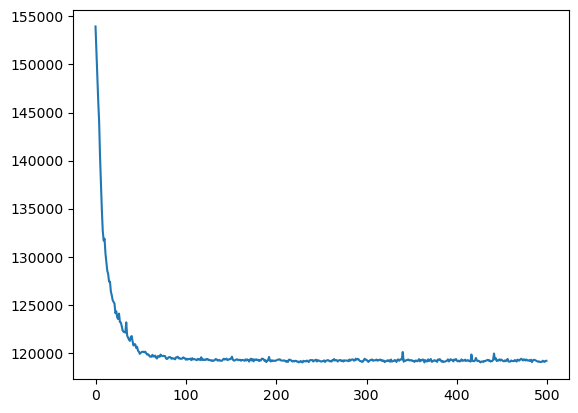

In [23]:
from pyro import subsample
from pyro.optim import ClippedAdam
from pyro.infer.autoguide import AutoGuideList

pyro.clear_param_store()
# optimizer = Adam("lr":0.01")
simple_model = poutine.condition(model, data={"affected": torch.zeros((args_pretrain[0].shape[0], 1))})
simple_guide = AutoNormal(
    poutine.block(simple_model, hide=["affected", "counts", "is_target"]),
    init_loc_fn=init_to_value(values={"mean": gene_mean}, fallback=init_to_median(num_samples=100)),
)

# simple_mixture_guide = AutoGuideList(simple_model, create_plates=create_plates)
# simple_mixture_guide.append(beta_guide)
# simple_mixture_guide.append(
#     AutoNormal(
#         poutine.block(simple_model, hide=["affected", "counts", "is_target", "trans_effect"]),
#         init_loc_fn=init_to_value(values={"mean": gene_mean}, fallback=init_to_median(num_samples=100)),
#     )
# )

# simple_svi = SVI(simple_model, simple_guide, ClippedAdam({"lr": 0.1}), loss=TraceEnum_ELBO(max_plate_nesting=3))
simple_svi = SVI(simple_model, simple_guide, ClippedAdam({"lr": 0.1}), loss=TraceEnum_ELBO(max_plate_nesting=3))


losses = []
for _ in tqdm(range(500)):
    loss = simple_svi.step(*args_pretrain, **kwargs_pretrain)
    losses.append(loss)
plt.plot(losses)

torch.Size([20729, 50]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64
torch.Size([25, 50]) torch.int64


100%|██████████| 500/500 [01:12<00:00,  6.88it/s]


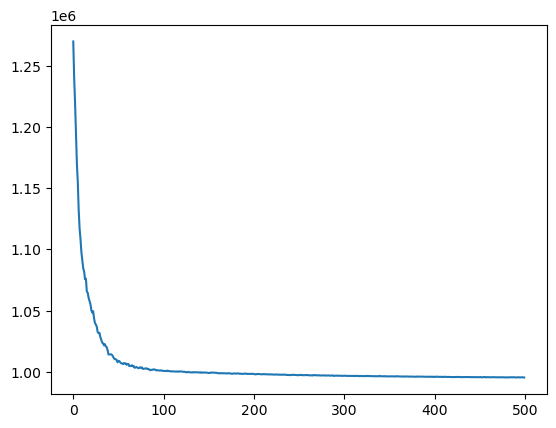

In [24]:
init_values = simple_guide.median()
init_values.pop("ppc_factors")
init_values.pop("perturbation_score")
guide = AutoNormal(
    poutine.block(model, hide=["affected", "counts", "is_target"]),
    init_loc_fn=init_to_value(values=init_values, fallback=init_to_median(num_samples=100)),
)
elbo = TraceEnum_ELBO(max_plate_nesting=3)
# elbo = JitTraceEnum_ELBO(max_plate_nesting=3)
# optimizer = Adam({"lr": 0.1})
pyro.clear_param_store()

# args = (None, perturbations)
for a in args:
    if a is not None:
        print(a.shape, a.dtype)

epochs = 500
if "subsample_size" in kwargs:
    steps = epochs * int(adata_subset.n_obs / kwargs["subsample_size"])
    optimizer = ClippedAdam({"lr": 0.1, "lrd": 1 - (5 / steps)})
else:
    steps = epochs
    optimizer = ClippedAdam({"lr": 0.1, "lrd": 0.995})
lr_decay = 1 - (5 / epochs)

svi = SVI(model, guide, optimizer, loss=elbo)
losses = []

for _ in tqdm(range(steps)):
    loss = svi.step(*args, **kwargs)
    losses.append(loss)
plt.plot(losses)

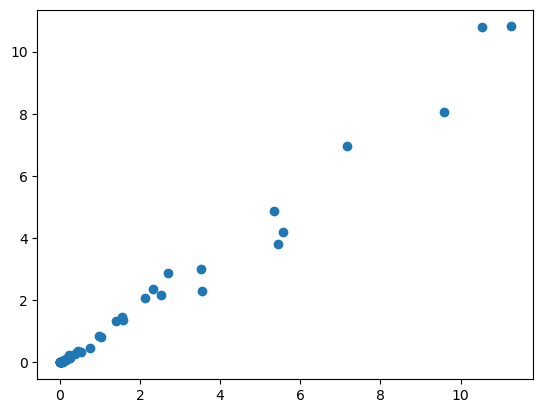

In [25]:
plt.scatter(adata_subset.X.mean(axis=0).A1, simple_guide.median()["mean"])

[]

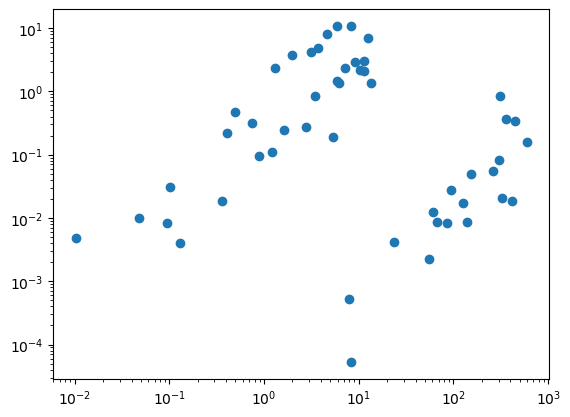

In [26]:
plt.scatter(simple_guide.median()["dispersion"], simple_guide.median()["mean"])
plt.loglog()

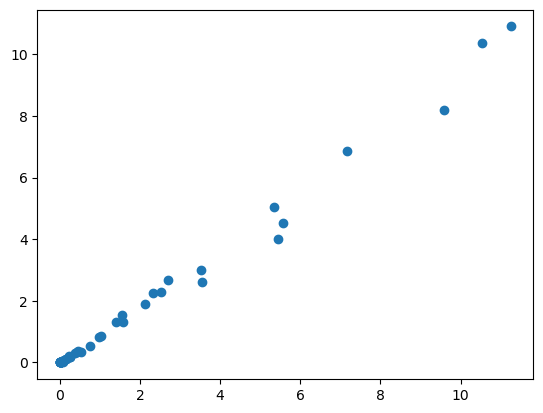

In [27]:
# sanity check: make sure gene means roughly agree with observed mean
plt.scatter(adata_subset.X.mean(axis=0).A1, guide.median()["mean"])

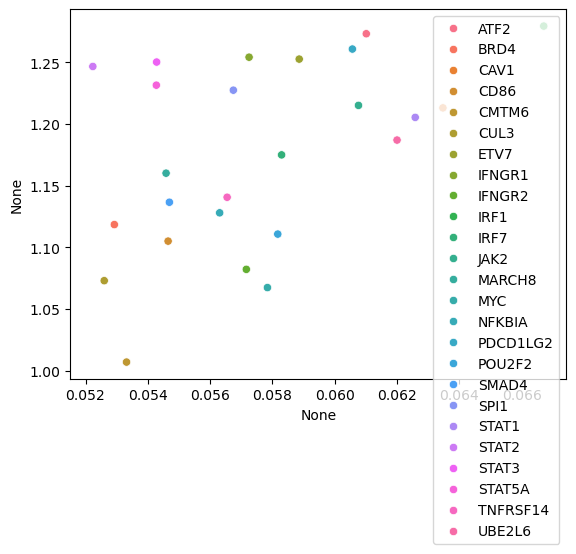

In [28]:
offset = guide.median()["trans_effect_offset"].squeeze()
k = guide.median()["trans_effect_k"].squeeze()
sns.scatterplot(x=offset,y=k,hue=elements)
plt.legend()
# median_efficiency = pd.DataFrame(
#     guide.median()["offset"], index=list(guide_mapping.keys())[:n_guides], columns=["offset"]
# ).assign(
#     guide=lambda x: x.index,
#     element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
# )
# median_efficiency.hist("efficiency")

array([[<Axes: title={'center': 'efficiency'}>]], dtype=object)

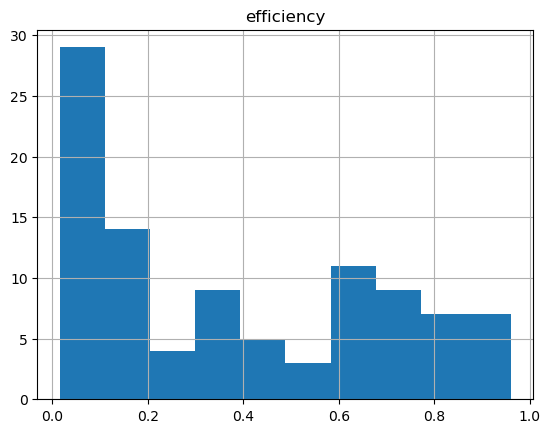

In [29]:
median_efficiency = pd.DataFrame(
    guide.median()["efficiency"], index=list(guide_mapping.keys())[:n_guides], columns=["efficiency"]
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

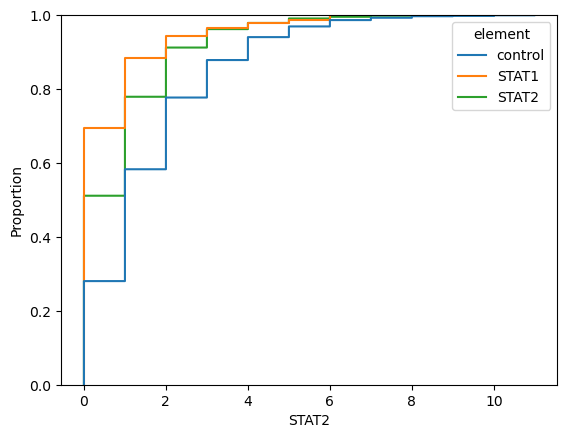

In [30]:
adata_subset[:, "STAT2"].X.mean()
stat_counts = adata_subset[:, ["STAT1", "STAT2"]].to_df().assign(element=adata_subset.obs["element"])
sns.ecdfplot(stat_counts, x="STAT2", hue="element", hue_order=["control", "STAT1", "STAT2"])
plt.show()

<Axes: xlabel='STAT1', ylabel='Proportion'>

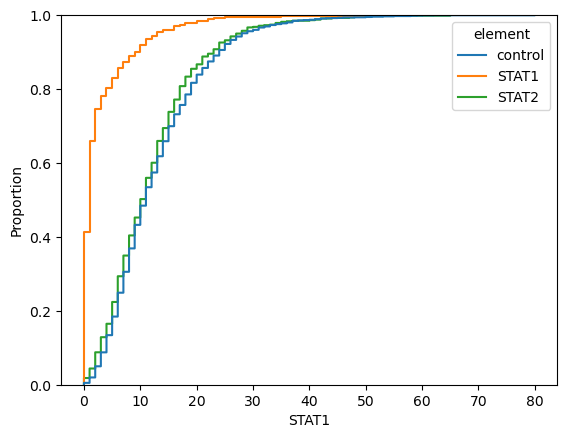

In [31]:
sns.ecdfplot(stat_counts, x="STAT1", hue="element", hue_order=["control", "STAT1", "STAT2"])

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24],
 [Text(0, 0, 'ATF2'),
  Text(1, 0, 'BRD4'),
  Text(2, 0, 'CAV1'),
  Text(3, 0, 'CD86'),
  Text(4, 0, 'CMTM6'),
  Text(5, 0, 'CUL3'),
  Text(6, 0, 'ETV7'),
  Text(7, 0, 'IFNGR1'),
  Text(8, 0, 'IFNGR2'),
  Text(9, 0, 'IRF1'),
  Text(10, 0, 'IRF7'),
  Text(11, 0, 'JAK2'),
  Text(12, 0, 'MARCH8'),
  Text(13, 0, 'MYC'),
  Text(14, 0, 'NFKBIA'),
  Text(15, 0, 'PDCD1LG2'),
  Text(16, 0, 'POU2F2'),
  Text(17, 0, 'SMAD4'),
  Text(18, 0, 'SPI1'),
  Text(19, 0, 'STAT1'),
  Text(20, 0, 'STAT2'),
  Text(21, 0, 'STAT3'),
  Text(22, 0, 'STAT5A'),
  Text(23, 0, 'TNFRSF14'),
  Text(24, 0, 'UBE2L6')])

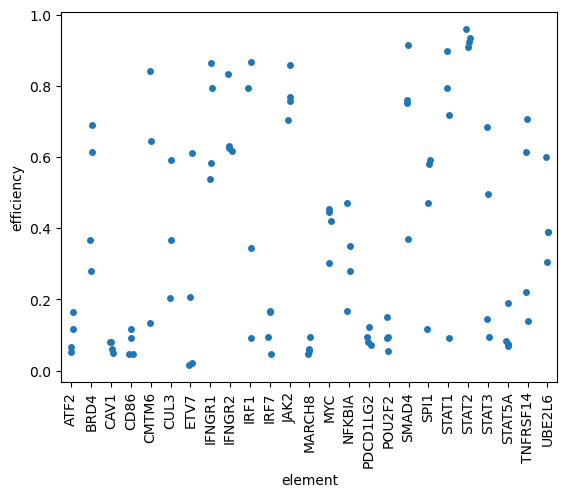

In [32]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

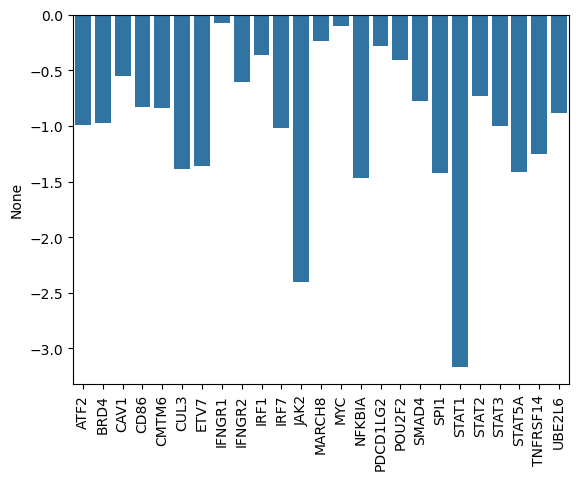

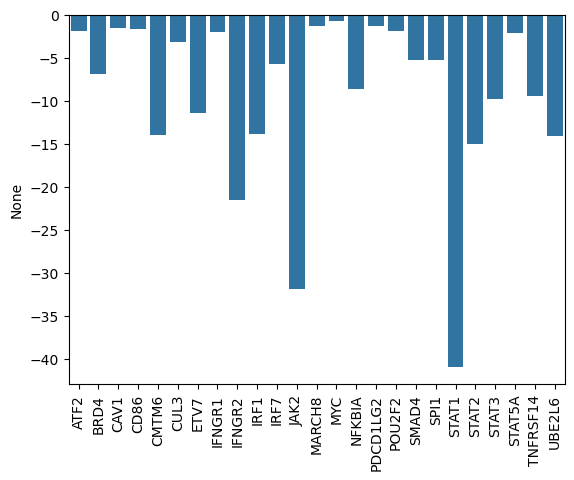

In [33]:
median_cis_effect = guide.median()["cis_effect"]
low_cis_effect, high_cis_effect = guide.quantiles([0.159, 0.841])["cis_effect"]
sigma_cis_effect = high_cis_effect - median_cis_effect
z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(x=element_mapping.keys(), y=median_cis_effect.squeeze())
plt.xticks(rotation=90)
plt.show()

sns.barplot(x=element_mapping.keys(), y=z_score_cis_effect.squeeze())

plt.xticks(rotation=90)
plt.show()

In [34]:
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

median_effect = guide.median()["trans_effect"]
low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"]
sigma_effect = high_effect - low_effect
z_score_effect = median_effect / sigma_effect

effects_df = pd.DataFrame(
    z_score_effect,
    columns=adata_subset.var_names,
    index=list(element_mapping.keys())[:n_elements],
)
effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

gene_symbol,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,RP11-54O7.18,C1orf159,TNFRSF18,TNFRSF4,SDF4,B3GALT6,FAM132A,RP5-902P8.12,UBE2J2,SCNN1D
ATF2,0.082189,-0.072415,-0.009288,0.017865,-0.092890,0.110674,0.087841,0.173144,-0.116265,-0.110043,...,0.060750,0.149953,0.031139,-0.014206,0.196491,0.051877,-0.174031,0.031385,-0.018442,-0.056343
BRD4,-0.131823,-0.000916,-0.024708,-1.381654,-0.344007,-0.518897,1.957693,-1.074828,0.703480,1.630969,...,0.015553,-0.155679,-0.156645,-0.014069,0.611332,-0.306411,-0.080484,-0.125069,-1.135821,-0.027755
CAV1,0.052814,-0.078203,-0.126112,0.079035,0.132520,-0.083841,0.073090,-0.145182,0.040048,0.001066,...,0.022951,-0.173237,-0.042959,0.065183,0.033583,0.007051,0.016226,-0.089424,-0.020729,0.195052
CD86,-0.032119,0.036669,-0.097349,-0.051966,0.469603,-0.101064,0.132811,-0.100771,0.098313,0.057533,...,-0.134259,-0.024319,0.032133,0.045204,0.252690,-0.145971,-0.018617,0.013459,0.094151,-0.024286
CMTM6,-0.135264,0.239503,0.404907,-0.218828,0.029387,0.086046,-0.329747,-0.263342,0.473513,-0.215788,...,0.155943,-0.038650,0.063334,-0.077884,-0.294202,0.139025,-0.097227,-0.053878,-0.474730,0.151443
CUL3,-0.116457,-0.289855,3.942855,0.154725,-0.048053,0.112568,0.267565,1.338648,-0.670090,0.613329,...,0.128731,-0.056874,-0.078289,-0.009254,-1.418071,-0.191775,-0.161104,-0.001131,-0.074153,0.179270
ETV7,-0.015798,-0.195253,0.096717,-0.191455,0.333511,0.133488,0.056208,-0.115325,0.041198,0.667245,...,-0.137954,0.072396,-0.117991,-0.130464,-0.367329,-0.046897,0.272942,0.144206,0.422918,0.165964
IFNGR1,0.810826,0.206801,-0.313509,-0.996566,-2.243254,2.686468,-16.531237,0.120722,5.763545,-32.577850,...,-0.016564,-0.098037,-0.062893,0.296595,2.498073,1.560082,0.901965,-0.120880,3.014834,-0.025521
IFNGR2,0.752209,1.577335,0.045848,-2.175946,-1.555101,2.703781,-16.514210,4.704474,0.176973,-33.382030,...,-0.074286,-0.589470,0.007833,0.400391,1.364501,1.666136,-0.141579,0.038332,1.578199,-0.246417
IRF1,0.139355,1.247371,-0.200244,3.156548,0.341728,-0.134415,-10.165531,0.473523,-0.807096,-0.013484,...,0.039702,-0.312684,0.099434,1.189469,0.549362,0.234087,-0.318183,-0.032657,-0.102931,-0.032025


In [35]:
plot_genes = list(effects_df.index)
plot_genes

['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

In [36]:
# effect_variance = effects_df.var(axis=0)
# effect_variance = effects_df.abs().sum(axis=0)
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
effect_variance = (effects_df.loc[["STAT3", "STAT5A","CAV1","CD86"]].abs()).sum(axis=0)
hvgs = effect_variance.nlargest(50).index
effects_df[hvgs]

gene_symbol,CMTM6,UBE2L6,NFKBIA,IRF7,ETV7,SPI1,PLEKHN1,SDF4,STAT3,JAK2,...,RP4-669L17.10,UBE2J2,SAMD11,AL627309.1,TNFRSF4,NOC2L,TNFRSF18,LINC00115,FAM132A,IRF1
ATF2,-0.092890,0.393743,-0.064115,0.084643,0.087841,0.122978,0.288112,0.196491,-0.135535,0.440282,...,0.047976,-0.018442,-0.028067,0.052091,-0.014206,-0.070255,0.031139,0.044530,-0.174031,-0.110043
BRD4,-0.344007,1.225008,3.530245,-3.294075,1.957693,-2.882537,-0.120921,0.611332,0.244794,1.048310,...,0.033470,-1.135821,0.149841,-0.091588,-0.014069,0.368356,-0.156645,0.255770,-0.080484,1.630969
CAV1,0.132520,-0.208373,0.019346,0.107467,0.073090,-0.046149,0.077577,0.033583,0.310250,0.094734,...,-0.068871,-0.020729,-0.032168,-0.031670,0.065183,-0.072027,-0.042959,0.041343,0.016226,0.001066
CD86,0.469603,0.301473,0.236012,-0.025530,0.132811,0.183576,-0.134610,0.252690,0.062089,0.229042,...,-0.008647,0.094151,0.047020,0.088929,0.045204,0.020303,0.032133,0.051926,-0.018617,0.057533
CMTM6,0.029387,-0.016265,-0.155945,-0.473615,-0.329747,-0.066805,0.287827,-0.294202,0.079839,0.086716,...,0.067949,-0.474730,-0.215518,0.081593,-0.077884,-0.023109,0.063334,0.042292,-0.097227,-0.215788
CUL3,-0.048053,0.019051,2.691630,-1.211118,0.267565,1.804996,-0.042785,-1.418071,-0.467066,-0.622988,...,0.089927,-0.074153,0.112009,0.038364,-0.009254,-0.674309,-0.078289,0.166551,-0.161104,0.613329
ETV7,0.333511,-0.202558,0.032826,0.427512,0.056208,-0.066669,0.114354,-0.367329,0.415264,0.176400,...,0.095214,0.422918,0.019297,0.079311,-0.130464,-0.273436,-0.117991,-0.035528,0.272942,0.667245
IFNGR1,-2.243254,-24.171701,4.989261,-15.107169,-16.531237,-2.467844,0.722009,2.498073,-7.609817,-17.112770,...,0.108074,3.014834,0.041236,-0.256212,0.296595,3.783314,-0.062893,0.005899,0.901965,-32.577850
IFNGR2,-1.555101,-24.741863,5.003733,-16.538950,-16.514210,-2.762484,0.020447,1.364501,-7.619641,-18.926607,...,0.073488,1.578199,-0.018792,-0.250415,0.400391,3.342153,0.007833,0.185331,-0.141579,-33.382030
IRF1,0.341728,-3.418224,0.785722,0.256463,-10.165531,-1.267160,-0.043262,0.549362,0.743870,-11.132092,...,0.031678,-0.102931,0.129397,0.506463,1.189469,0.362651,0.099434,-0.172278,-0.318183,-0.013484


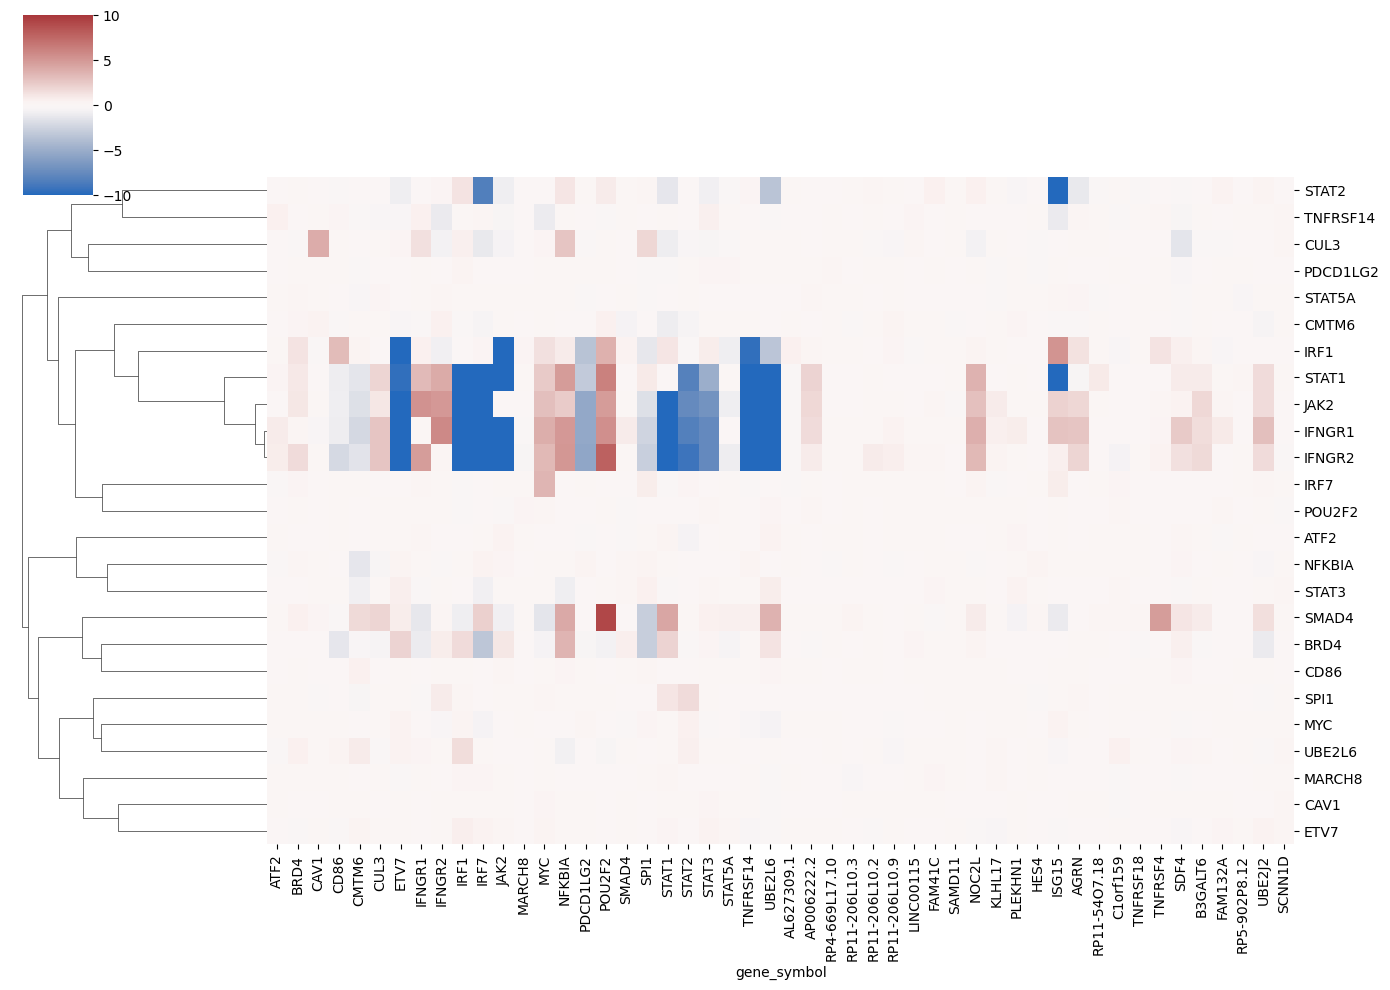

In [37]:
sns.clustermap(effects_df, vmax=10, vmin=-10, cmap="vlag", metric="cosine", figsize=(14, 10), col_cluster=False)


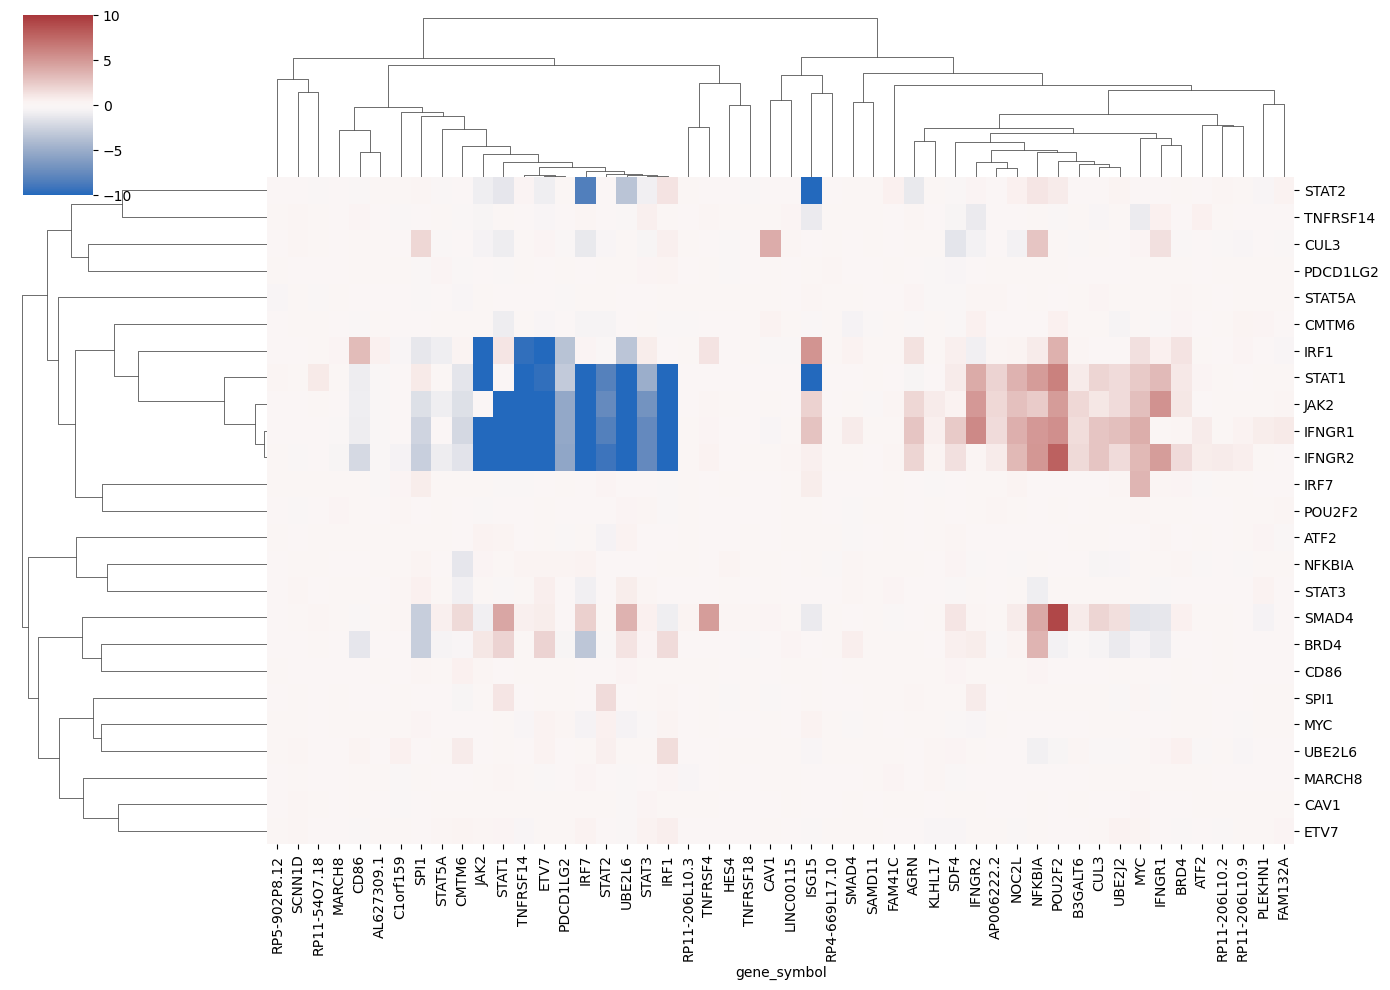

In [38]:
sns.clustermap(effects_df[hvgs], vmax=10, vmin=-10, cmap="vlag", metric="cosine", figsize=(14, 10))

In [39]:
pyro.get_param_store().save("params.save")

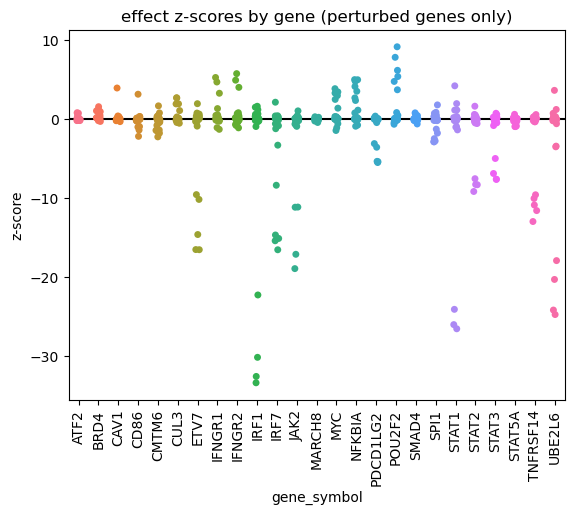

In [40]:
n_plot_genes=25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
# 
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

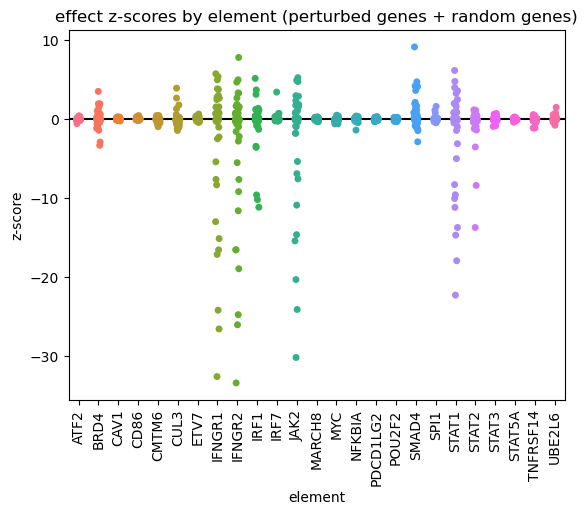

In [41]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("z-score")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [42]:
effects_df.T["CUL3"].sort_values()

gene_symbol
SDF4            -1.418071
IRF7            -1.211118
STAT1           -1.011541
NOC2L           -0.674309
IFNGR2          -0.670090
JAK2            -0.622988
STAT3           -0.467066
RP11-206L10.9   -0.374999
STAT2           -0.321401
BRD4            -0.289855
STAT5A          -0.253823
HES4            -0.242471
RP11-206L10.2   -0.206881
PDCD1LG2        -0.196510
B3GALT6         -0.191775
FAM132A         -0.161104
ISG15           -0.131529
ATF2            -0.116457
TNFRSF18        -0.078289
UBE2J2          -0.074153
SMAD4           -0.069336
C1orf159        -0.056874
MARCH8          -0.051393
AP006222.2      -0.049741
CMTM6           -0.048053
PLEKHN1         -0.042785
TNFRSF4         -0.009254
FAM41C          -0.007148
RP5-902P8.12    -0.001131
UBE2L6           0.019051
AL627309.1       0.038364
POU2F2           0.061597
KLHL17           0.062342
TNFRSF14         0.064677
AGRN             0.067613
RP11-206L10.3    0.072786
RP4-669L17.10    0.089927
SAMD11           0.112009


In [43]:
alpha = 0.001
level = alpha / (n_genes * n_elements)
low, high = guide.quantiles([level, 1 - level])["trans_effect"]
(low < 0) & (high > 0)

tensor([[True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        ...,
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True],
        [True, True, True,  ..., True, True, True]])

In [44]:
guide.median()

{'ppc_factors': tensor([[[-1.0886],
          [-0.6905],
          [-0.3481],
          ...,
          [-0.2028],
          [ 0.4254],
          [ 0.5815]],
 
         [[ 0.0323],
          [-0.2764],
          [ 0.4525],
          ...,
          [ 0.0427],
          [-0.3405],
          [ 0.4527]],
 
         [[ 0.2204],
          [-0.4609],
          [ 0.6796],
          ...,
          [-0.1814],
          [-0.0634],
          [-1.0648]],
 
         [[-0.7040],
          [ 0.4131],
          [ 0.7423],
          ...,
          [-0.5050],
          [ 1.4612],
          [ 0.1725]],
 
         [[ 2.0285],
          [ 0.4442],
          [-0.3362],
          ...,
          [-1.1338],
          [-0.2874],
          [ 0.1950]]]),
 'ppc_loadings': tensor([[[-9.7649e-02, -1.8053e-01, -3.4157e-01,  2.0220e-01, -2.9708e-02,
           -1.8815e-01, -4.3583e-03, -1.4987e-02,  4.2601e-04, -2.0003e-02,
           -6.6674e-02,  9.1228e-02, -2.5373e-02, -9.2208e-03, -2.1735e-01,
            1.8604e-0

In [45]:
# if "subsample_size" in kwargs:
#     kwargs.pop("subsample_size")
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals

args_sim = (None, *args[1:])
counts_simulated = trained_model(*args_sim, **kwargs)


# def classifier(args, temperature=0):
#     inferred_model = infer_discrete(
#         trained_model, temperature=temperature, first_available_dim=-3
#     )  # avoid conflict with data plate
#     trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
#     return trace.nodes["has_guide"]["value"]

adata_subset.obs["perturbation"]
# print(classifier(args))

AAACCTGAGCCAGAAC    STAT2g2
AAACCTGAGTGGACGT     CAV1g4
AAACCTGCATGAGCGA    STAT1g2
AAACCTGTCTTGTCAT     CD86g1
AAACGGGAGAACAACT     IRF7g2
                     ...   
TTTGTCAGTCACTTCC    CMTM6g1
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA     ATF2g1
TTTGTCATCACGCATA     CAV1g2
TTTGTCATCTGTACGA    STAT3g1
Name: perturbation, Length: 20729, dtype: category
Categories (99, object): ['ATF2g1', 'ATF2g2', 'ATF2g3', 'ATF2g4', ..., 'UBE2L6g2', 'UBE2L6g3', 'UBE2L6g4', 'control']

In [46]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# gene_idx = 0
# counts_simulated_col = counts_simulated[:, gene_idx]
# counts_real_col = adata_subset[:, gene_idx].X.todense().A1
# max_count = int(max(counts_simulated_col.max(), counts_real_col.max()))
# # counts_simulated_col.shape
# # perts.shape
# plot_guides = ["control"] + [f"STAT1g{i}" for i in range(1, 5)]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.scatterplot(x=counts_real_col[perts], y=counts_simulated_col[perts], label=guide_id, alpha=0.1)
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     plt.title(guide_id)
#     sns.histplot(x=counts_real_col[perts], bins=range(max_count + 1), label="real")
#     sns.histplot(x=counts_simulated_col[perts], bins=range(max_count + 1), label="simulated")
#     plt.legend()
#     plt.semilogy()
#     plt.show()

In [47]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts_simulated_col = counts_simulated[:, 0]
# counts_simulated_col.shape
# perts.shape
# plot_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     sns.kdeplot(x=counts_simulated_col[perts], label=guide_id)
#     # plt.show()
# plt.legend()

In [48]:
for k, v in guide.median().items():
    print(k, v.shape, v.dtype)

ppc_factors torch.Size([5, 20729, 1]) torch.float32
ppc_loadings torch.Size([5, 1, 50]) torch.float32
efficiency torch.Size([98, 1]) torch.float32
mean torch.Size([50]) torch.float32
dispersion torch.Size([50]) torch.float32
extra_dispersion torch.Size([50]) torch.float32
perturbation_score torch.Size([20729, 1]) torch.float32
cis_effect torch.Size([25, 1]) torch.float32
trans_effect_offset torch.Size([25, 1]) torch.float32
trans_effect_k torch.Size([25, 1]) torch.float32
trans_effect torch.Size([25, 50]) torch.float32


In [49]:
for a in args:
    print(a.shape, a.dtype)
for k, v in kwargs.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape, v.dtype)
    else:
        print(k, v)

torch.Size([20729, 50]) torch.int32
torch.Size([20729]) torch.int64
torch.Size([20729]) torch.int64
torch.Size([25, 50]) torch.int64
size_factor torch.Size([20729, 1]) torch.float32
n_factors 5
n_genes 50


In [50]:
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(poutine.block(model, hide=["is_target"]), trace=guide_trace)  # replay the globals


def classifier(args, kwargs, temperature=0):
    inferred_model = infer_discrete(
        trained_model, temperature=temperature, first_available_dim=-5
    )
    trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
    return trace.nodes["affected"]["value"]


map_labels = classifier(args, kwargs, temperature=0)
map_labels
# adata_subset.obs[["perturbation"]].assign(affected=map_labels).value_counts(["perturbation", "affected"])
# x.value_counts()
# torch.mean(classifier((None, perturbations), kwargs))

tensor([[1.],
        [0.],
        [1.],
        ...,
        [0.],
        [0.],
        [1.]])

(array([2.0000e+00, 0.0000e+00, 1.0000e+00, 4.0000e+00, 2.0000e+00,
        3.0000e+00, 5.0000e+00, 3.0000e+00, 4.0000e+00, 7.0000e+00,
        1.0000e+01, 4.0000e+00, 1.0000e+01, 2.2000e+01, 2.3000e+01,
        3.8000e+01, 5.3000e+01, 4.4000e+01, 8.8000e+01, 1.1700e+02,
        1.4000e+02, 1.9500e+02, 2.5000e+02, 3.3000e+02, 3.9300e+02,
        4.6000e+02, 5.3300e+02, 5.8600e+02, 5.8000e+02, 1.4484e+04,
        4.1800e+02, 3.3100e+02, 2.7100e+02, 2.1900e+02, 1.7500e+02,
        1.4300e+02, 1.2500e+02, 9.6000e+01, 7.7000e+01, 6.8000e+01,
        5.7000e+01, 5.2000e+01, 4.4000e+01, 3.6000e+01, 2.8000e+01,
        2.9000e+01, 1.9000e+01, 2.3000e+01, 2.1000e+01, 1.3000e+01,
        9.0000e+00, 1.2000e+01, 1.1000e+01, 9.0000e+00, 5.0000e+00,
        6.0000e+00, 4.0000e+00, 5.0000e+00, 1.0000e+00, 3.0000e+00,
        3.0000e+00, 4.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00,
        2.0000e+00, 1.0000e+00, 1.0000e+00, 3.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 0.0000e+00, 1.00

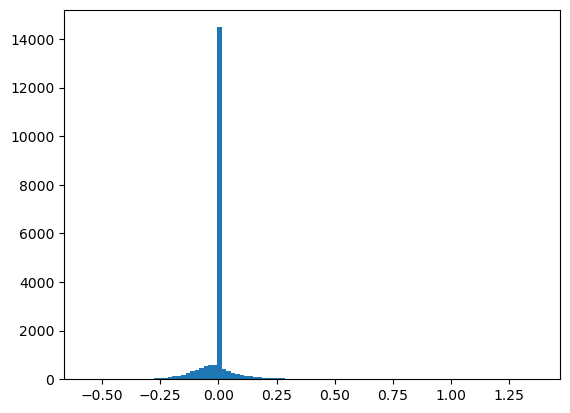

In [51]:
plt.hist(guide.median()["perturbation_score"].ravel() * map_labels.ravel(), bins=100)

(array([9678., 2074.,  978.,  676.,  540.,  512.,  500.,  567.,  638.,
        4566.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

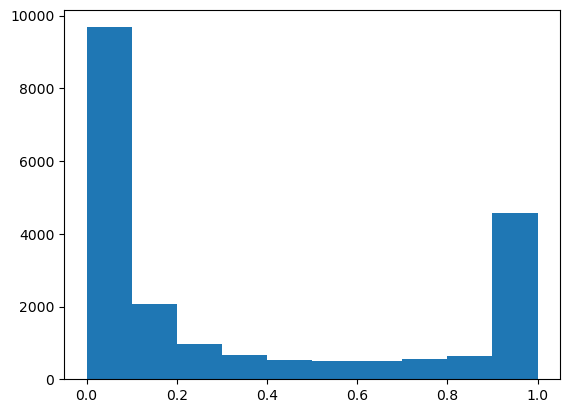

In [52]:
n_posterior_samples = 100
posterior_samples = (
    sum(classifier(args, kwargs, temperature=1) for _ in range(n_posterior_samples)) / n_posterior_samples
)
posterior_samples.mean()
plt.hist(posterior_samples.squeeze())
# plt.semilogy()

/var/folders/w9/llll0v7j02zdytwd43sshysm0000gp/T/ipykernel_86033/2540703295.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


<Axes: xlabel='None', ylabel='Density'>

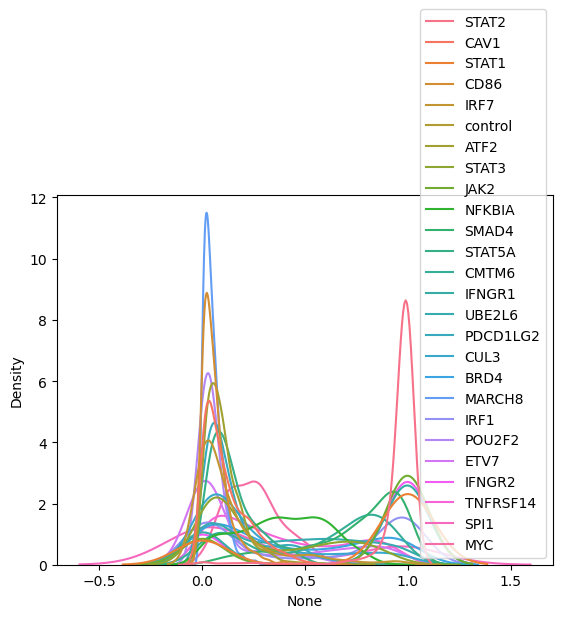

In [53]:
sns.kdeplot(
    x=posterior_samples.squeeze(),
    hue=adata_subset.obs["element"].values.squeeze(),
    common_norm=False,
    # hue_order=["IFNGR1", "IFNGR2","STAT1", "STAT2", "control"],
)

In [54]:
tolerance = 0.01
posterior_samples[(posterior_samples < (1 - tolerance)) & (posterior_samples > tolerance)]

tensor([0.3000, 0.0300, 0.0900,  ..., 0.1900, 0.1900, 0.9400])